# **TARDIS_MODEL**

> **Auteur :** Laurince AGANI  
> **Dataset :** `cleaned_dataset.csv`, Retards ferroviaires SNCF, réseau grandes lignes  
> **Objectif :** Prédire le retard moyen à l'arrivée (`Average delay of all trains at arrival`) et identifier les causes opérationnelles qui l'expliquent.

---

Ce notebook suit un pipeline ML complet en 7 étapes :

1. Importation des librairies et configuration
2. Chargement et inspection des données
3. Préprocessing
   - 3.1 Feature Engineering
   - 3.2 Séparation Train/Test
   - 3.3 Construction du pipeline sklearn
4. Entraînement des modèles
5. Évaluation et comparaison
6. Hyperparameter Tuning
7. Sauvegarde du modèle

## 1. Imports et configuration

On commence par importer toutes les librairies dont on aura besoin. Les regrouper en début de notebook est une bonne pratique : ça évite les surprises à mi-chemin et rend les dépendances visibles d'un coup d'œil.

- **pandas / numpy:** manipulation et calcul sur les données
- **matplotlib / seaborn:** visualisation
- **scikit-learn:** preprocessing, modèles, évaluation, pipelines
- **joblib / json / os:** sauvegarde du modèle et des métadonnées

On définit aussi deux constantes globales réutilisées partout : `TARGET` (la variable à prédire) et `SEED` (pour la reproductibilité).

In [1]:
# Manipulation de données
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Scikit-learn: Préprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Scikit-learn: Modèles de régression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)

# Scikit-learn: Evaluation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Scikit-learn: Dummy
from sklearn.dummy import DummyRegressor

# Sauvegarde du modèle
import joblib
import json

# Utilitaires
import os
import warnings

warnings.filterwarnings("ignore")

# Colonne à prédire
TARGET = "Average delay of all trains at arrival"

# SEED
SEED = 42

## 2. Chargement et inspection des données

Avant d'entraîner quoi que ce soit, il faut comprendre ce qu'on a entre les mains.

Le fichier utilise `;` comme séparateur donc sans `sep=';'`, pandas lirait tout comme une seule colonne.

On inspecte ensuite les premières lignes, les types de colonnes, et les statistiques descriptives. C'est à cette étape qu'on repère les anomalies évidentes : valeurs manquantes, outliers, colonnes mal typées.

In [2]:
# Chargement du dataset
df = pd.read_csv("cleaned_dataset.csv", sep=";", encoding="utf-8")

# Inspection initiale du dataset
print("=" * 84)
print("APERÇU DES 5 PREMIÈRES LIGNES")
print("=" * 84)
display(df.head(5))

# Forme du dataset
print("Dimensions du dataset")
print(f"    {df.shape[0]} observations")
print(f"    {df.shape[1]} features")

APERÇU DES 5 PREMIÈRES LIGNES


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,...,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",Year,Month,Delay categories,is_delayed,Cancellation_rate
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,289.0,11.247809,3.693179,...,31.092437,10.924370,15.966387,5.040000,0.840336,2018,1,average delay,1,0.005747
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,213.0,8.479969,4.567119,...,35.000000,16.666667,16.666667,8.333333,3.333333,2018,1,average delay,1,0.002463
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,21.0,6.239683,0.286283,...,27.777778,16.666667,16.666667,5.555556,11.111111,2018,1,minor delay,0,0.000000
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,71.0,7.235211,0.980000,...,22.222222,16.666667,20.370370,5.555556,1.851852,2018,1,average delay,1,0.005906
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,224.0,6.784673,3.229701,...,45.614035,18.750000,15.789474,1.754386,1.754386,2018,1,minor delay,0,0.008475


Dimensions du dataset
    11487 observations
    28 features


In [3]:
# Informations sur le dataset
print("=" * 84)
print("INFORMATIONS SUR LE DATASET")
print("=" * 84)
df.info()

INFORMATIONS SUR LE DATASET
<class 'pandas.DataFrame'>
RangeIndex: 11487 entries, 0 to 11486
Data columns (total 28 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   Date                                                                           11487 non-null  str    
 1   Service                                                                        11487 non-null  str    
 2   Departure station                                                              11487 non-null  str    
 3   Arrival station                                                                11487 non-null  str    
 4   Average journey time                                                           11487 non-null  float64
 5   Number of scheduled trains                                                     11487 non-null  float64
 6   Numbe

In [4]:
# Statistiques descriptives du dataset
print("=" * 84)
print("STATISTIQUES DESCRIPTIVES DU DATASET")
print("=" * 84)
df.describe().round(2)

STATISTIQUES DESCRIPTIVES DU DATASET


,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,Number of trains delayed at arrival,Average delay of late trains at arrival,Average delay of all trains at arrival,Number of trains delayed > 15min,...,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",Year,Month,is_delayed,Cancellation_rate
count,11487.00,11487.00,11487.00,11487.00,11487.00,11487.00,11487.00,11487.00,11487.00,11487.00,...,11487.00,11487.00,11487.00,11487.00,11487.00,11487.00,11487.00,11487.00,11487.00,11477.00
mean,170.72,269.85,8.52,86.13,12.28,3.11,37.23,35.17,6.03,26.72,...,21.52,21.83,20.34,18.82,7.33,7.52,2021.48,6.51,0.55,inf
std,87.16,181.15,22.49,89.89,11.80,5.15,30.98,15.60,7.04,22.43,...,15.81,14.74,14.52,13.35,7.93,9.36,2.31,3.45,0.50,NaN
min,0.00,0.00,0.00,0.00,0.00,-229.27,0.00,-40.11,-472.64,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,2018.00,1.00,0.00,0.00
25%,101.00,152.00,0.00,22.00,6.28,1.22,15.00,25.95,3.43,11.00,...,10.71,12.16,10.53,10.19,0.00,0.00,2019.00,4.00,0.00,0.00
50%,164.00,229.00,2.00,52.00,10.38,2.33,29.00,33.47,5.35,21.00,...,19.05,20.00,18.75,17.11,5.88,5.00,2021.00,7.00,1.00,0.01
75%,222.00,351.00,7.00,125.00,15.57,3.89,50.00,42.25,8.00,36.00,...,29.41,29.41,28.18,25.00,10.87,11.11,2024.00,9.00,1.00,0.03
max,786.00,1100.00,297.00,1066.00,316.19,115.05,376.00,299.60,92.00,312.00,...,100.00,100.00,100.00,100.00,100.00,100.00,2025.00,12.00,1.00,inf


In [5]:
# Analyse des valeurs manquantes

# Afficher les colonnes avec des valeurs manquantes
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() * 100) / len(df)

missing_df = pd.DataFrame(
    {"Valeurs manquantes": missing, "Pourcentage (%)": missing_pct.round(2)}
).sort_values("Pourcentage (%)", ascending=False)

missing_with_nan = missing_df[missing_df["Valeurs manquantes"] > 0]

print("=" * 84)
print("VALEURS MANQUANTES PAR COLONNE")
print("=" * 84)
if len(missing_with_nan) == 0:
    print("Aucune valeur manquante détectée !")
else:
    display(missing_with_nan)
    print(f"{len(missing_with_nan)} colonnes contiennent des valeurs manquantes.")

VALEURS MANQUANTES PAR COLONNE


,Valeurs manquantes,Pourcentage (%)
Cancellation_rate,10,0.09


1 colonnes contiennent des valeurs manquantes.


In [6]:
# Distribution de la TARGET
print("=" * 84)
print(f"STATISTIQUES DE LA TARGET '{TARGET}'")
print("=" * 84)

print(f"Moyenne     : {df[TARGET].mean():.2f} minutes")
print(f"Médiane     : {df[TARGET].median():.2f} minutes")
print(f"Ecart-Type  : {df[TARGET].std():.2f} minutes")
print(f"Min         : {df[TARGET].min():.2f} minutes")
print(f"Max         : {df[TARGET].max():.2f} minutes")
print(f"Asymétrie   : {df[TARGET].skew():.3f}")

STATISTIQUES DE LA TARGET 'Average delay of all trains at arrival'
Moyenne     : 6.03 minutes
Médiane     : 5.35 minutes
Ecart-Type  : 7.04 minutes
Min         : -472.64 minutes
Max         : 92.00 minutes
Asymétrie   : -31.896


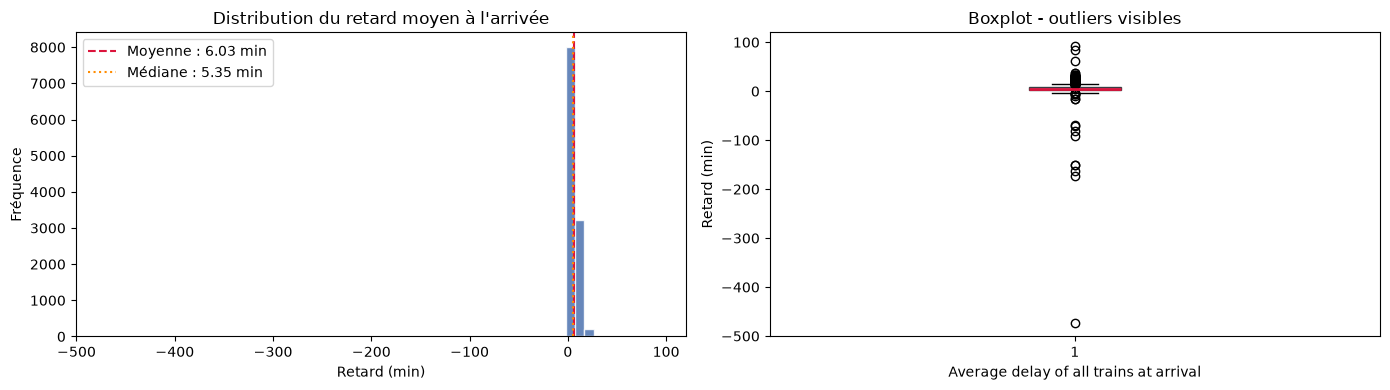

In [7]:
# Visualisation de la distribution de la TARGET
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme
axes[0].hist(
    df[TARGET].dropna(), bins=60, color="#4C72B0", edgecolor="white", alpha=0.85
)
axes[0].axvline(
    df[TARGET].mean(),
    color="crimson",
    linestyle="--",
    label=f"Moyenne : {df[TARGET].mean():.2f} min",
)
axes[0].axvline(
    df[TARGET].median(),
    color="darkorange",
    linestyle=":",
    label=f"Médiane : {df[TARGET].median():.2f} min",
)
axes[0].set_title("Distribution du retard moyen à l'arrivée")
axes[0].set_xlabel("Retard (min)")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

# Boxplot
axes[1].boxplot(
    df[TARGET].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", alpha=0.7),
    medianprops=dict(color="crimson", linewidth=2),
)
axes[1].set_title("Boxplot - outliers visibles")
axes[1].set_ylabel("Retard (min)")
axes[1].set_xlabel(TARGET)

plt.tight_layout()
plt.show()

### Distribution de la variable cible

Avant de modéliser, analyser la target est indispensable.

On observe une **asymétrie très forte** (skewness = -31.9) et un **minimum négatif** (-472 min). Un retard négatif n'a pas de sens physique - ce sont probablement des trains arrivés en avance ou des erreurs de saisie. Ces valeurs aberrantes sont traitées dans la section suivante avant toute modélisation.

### Traitement des outliers

Le graphique ci-dessus met en évidence des valeurs manifestement erronées (minimum à -472 min). On retire les observations dont le retard est inférieur à **-30 min**, seuil conservateur qui préserve les trains légèrement en avance (phénomène réel) tout en supprimant les artefacts de saisie.

In [8]:
# Filtrage des valeurs aberrantes sur la TARGET

seuil_min = -30

avant = len(df)
df = df[df[TARGET] >= seuil_min].copy()
apres = len(df)

print(
    f"Observations supprimées : {avant - apres:,}  ({(avant - apres) / avant * 100:.2f}% du dataset)"
)
print(f"Dataset conservé        : {apres:,} lignes")
print(f"Nouveau min TARGET      : {df[TARGET].min():.2f} min")
print(f"Nouvelle asymétrie      : {df[TARGET].skew():.3f}")

Observations supprimées : 9  (0.08% du dataset)
Dataset conservé        : 11,478 lignes
Nouveau min TARGET      : -15.19 min
Nouvelle asymétrie      : 2.804


## 3. Préprocessing

Les algorithmes ML ne comprennent que des nombres. Le préprocessing transforme les données brutes pour les rendre digestes :

- les colonnes texte (gares, service) -> encodage one-hot (`OneHotEncoder`)
- les colonnes numériques -> imputation des valeurs manquantes + normalisation Z-score
- le tout enchaîné dans un `Pipeline` sklearn, qui garantit qu'aucune information du test set ne "fuite" dans l'entraînement

On identifie d'abord le type de chaque colonne, puis on construit les sous-pipelines adaptés.

In [9]:
# Identification des colonnes par type

numeric_cols_all = df.select_dtypes(include=[np.number]).columns
df[numeric_cols_all] = df[numeric_cols_all].replace([np.inf, -np.inf], np.nan)

# Colonnes catégorielles
CATEGORICAL_COLS = [
    "Service",
    "Departure station",
    "Arrival station",
    "Delay categories",
]

# Colonnes temporelles
TEMPORAL_COLS = ["Date"]

# Colonnes exclues du préprocessing
EXCLUDE_COLS = ["is_delayed", "Date", TARGET]

# Colonnes numériques
NUMERICAL_COLS = [
    col
    for col in df.select_dtypes(include=[np.number]).columns
    if col not in EXCLUDE_COLS
]

print("=" * 84)
print("CLASSIFICATION DES COLONNES")
print("=" * 84)

print(f"\nColonnes catégorielles ({len(CATEGORICAL_COLS)}):")
for c in CATEGORICAL_COLS:
    print(f"    - {c} -> {df[c].nunique()} valeurs uniques")

print(f"\nColonnes numériques ({len(NUMERICAL_COLS)}):")
for c in NUMERICAL_COLS:
    print(f"    - {c}")

print(f"\nColonnes temporelles ({len(TEMPORAL_COLS)}):")
for c in TEMPORAL_COLS:
    print(f"    - {c}")

print(f"\nColonnes exclues ({len(EXCLUDE_COLS)}):")
for c in EXCLUDE_COLS:
    print(f"    - {c}")

CLASSIFICATION DES COLONNES

Colonnes catégorielles (4):
    - Service -> 2 valeurs uniques
    - Departure station -> 131 valeurs uniques
    - Arrival station -> 116 valeurs uniques
    - Delay categories -> 5 valeurs uniques

Colonnes numériques (21):
    - Average journey time
    - Number of scheduled trains
    - Number of cancelled trains
    - Number of trains delayed at departure
    - Average delay of late trains at departure
    - Average delay of all trains at departure
    - Number of trains delayed at arrival
    - Average delay of late trains at arrival
    - Number of trains delayed > 15min
    - Average delay of trains > 15min (if competing with flights)
    - Number of trains delayed > 30min
    - Number of trains delayed > 60min
    - Pct delay due to external causes
    - Pct delay due to infrastructure
    - Pct delay due to traffic management
    - Pct delay due to rolling stock
    - Pct delay due to station management and equipment reuse
    - Pct delay due to p

### 3.1 Feature Engineering

Créer de nouvelles variables à partir des données existantes est souvent ce qui fait la différence entre un bon et un excellent modèle.

On ajoute **7 features** réparties en deux groupes :

**Temporelles** (pour capturer les patterns saisonniers) :
- `month_sin` / `month_cos`: encodage cyclique du mois (décembre et janvier restent proches, contrairement à 12 et 1 en numérique brut)
- `season`: saison (hiver, printemps, été, automne)
- `is_peak_month`: indicateur des mois de forte affluence (juillet, août, décembre, janvier)

**Opérationnelles** (pour enrichir le signal sur l'état du réseau) :
- `cancellation_rate`: taux d'annulation (proxy de stress opérationnel)
- `pct_heavily_delayed`: part des trains retardés de plus de 15 min parmi les programmés
- `stress_score`: somme des causes infrastructure + trafic (facteurs peu contrôlables par la SNCF)

In [10]:
# Création de nouvelles features

df_feat = df.copy()

# Features temporelles cycliques
month_col = df_feat["Month"]

# Encodage cyclique du mois (décembre et janvier restent proches)
df_feat["month_sin"] = np.sin(2 * np.pi * month_col / 12)
df_feat["month_cos"] = np.cos(2 * np.pi * month_col / 12)

# Saison (1=hiver, 2=printemps, 3=été, 4=automne)
df_feat["season"] = pd.cut(
    month_col, bins=[0, 3, 6, 9, 12], labels=[1, 2, 3, 4], include_lowest=True
).astype(float)

# Mois de forte affluence
df_feat["is_peak_month"] = month_col.isin([7, 8, 12, 1]).astype(int)

# Features opérationnelles supplémentaires
# Taux d'annulation (proxy de stress opérationnel)
df_feat["cancellation_rate"] = df_feat["Number of cancelled trains"] / df_feat[
    "Number of scheduled trains"
].clip(lower=1)

# Part des trains fortement retardés (>15 min) parmi les programmés
df_feat["pct_heavily_delayed"] = df_feat["Number of trains delayed > 15min"] / df_feat[
    "Number of scheduled trains"
].clip(lower=1)

# Score de stress infrastructure+trafic (causes sur lesquelles la SNCF a peu de marge)
infra_col = "Pct delay due to infrastructure"
trafic_col = "Pct delay due to traffic management"
if infra_col in df_feat.columns and trafic_col in df_feat.columns:
    df_feat["stress_score"] = df_feat[infra_col] + df_feat[trafic_col]

n_new = df_feat.shape[1] - df.shape[1]
print(f"Features créées : {n_new}")
print(f"Dataset étendu  : {df_feat.shape[0]} lignes × {df_feat.shape[1]} colonnes")
new_cols = [c for c in df_feat.columns if c not in df.columns]
for c in new_cols:
    print(f"   + {c}")

Features créées : 7
Dataset étendu  : 11478 lignes × 35 colonnes
   + month_sin
   + month_cos
   + season
   + is_peak_month
   + cancellation_rate
   + pct_heavily_delayed
   + stress_score


### 3.2 Définition de la target et séparation Train/Test

On prédit `Average delay of all trains at arrival` : le retard moyen à l'arrivée, **toutes causes et tous trains confondus**. C'est la métrique la plus représentative de l'expérience passager.

On exclut plusieurs colonnes des features pour éviter la **fuite de données** (data leakage) : des variables comme `Number of trains delayed at arrival` ou `Average delay of late trains at arrival` contiennent de l'information directement liée à la target, les inclure serait tricher.

En revanche, `Departure station` et `Arrival station` sont **conservées** comme features catégorielles : certaines routes sont structurellement plus retardées que d'autres, ce qui est une information légitime pour le modèle.

Le split est 80/20 avec `random_state=42` pour garantir la reproductibilité. Les moyennes de `y_train` et `y_test` doivent être proches ; si elles divergent, le split est déséquilibré.

In [11]:
# Définition de la TARGET et des FEATURES

print("=" * 84)
print("DÉFINITION DES TARGETS ET SÉPARATION TRAIN/TEST")
print("=" * 84)

TARGET = "Average delay of all trains at arrival"

# Colonnes à exclure des features
EXCLUDE_FROM_FEATURES = [
    TARGET,
    "is_delayed",
    "Date",
    "Cancellation_rate",
    "Number of trains delayed at departure",
    "Number of trains delayed > 60min",
    "Number of trains delayed > 30min",
    "Number of trains delayed > 15min",
    "Number of trains delayed at arrival",
    "Average delay of late trains at departure",
    "Average delay of trains > 15min (if competing with flights)",
    "Average delay of late trains at arrival",
]

# Colonnes à utiliser comme features
FEATURE_COLS = [c for c in df_feat.columns if c not in EXCLUDE_FROM_FEATURES]

print(f"Features utilisées pour la régression : {len(FEATURE_COLS)}")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"   {i:2d}. {col}")

# Séparation X / y

# X = matrice de features (inputs)
# y = vecteur target (output à prédire)

X = df_feat[FEATURE_COLS].copy()
y = df_feat[TARGET].copy()

# Supprimer les lignes où la target est NaN
mask = y.notna()
X = X[mask]
y = y[mask]

print(f"\nX (features) : {X.shape}")
print(f"y (target)    : {y.shape}")

# Train / Test Split

# 80% d'entraînement, 20% de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, shuffle=True
)

print("\nRépartition Train/Test :")
print(
    f"   Train : {X_train.shape[0]:,} observations ({((X_train.shape[0] / len(X)) * 100):.1f}%)"
)
print(
    f"   Test  : {X_test.shape[0]:,} observations ({((X_test.shape[0] / len(X)) * 100):.1f}%)"
)

# Vérification de la distribution de y_train vs y_test
print("\nVérification de la distribution :")
print(f"   Moyenne y_train : {y_train.mean():.3f} min")
print(f"   Moyenne y_test  : {y_test.mean():.3f} min")

DÉFINITION DES TARGETS ET SÉPARATION TRAIN/TEST
Features utilisées pour la régression : 23
    1. Service
    2. Departure station
    3. Arrival station
    4. Average journey time
    5. Number of scheduled trains
    6. Number of cancelled trains
    7. Average delay of all trains at departure
    8. Pct delay due to external causes
    9. Pct delay due to infrastructure
   10. Pct delay due to traffic management
   11. Pct delay due to rolling stock
   12. Pct delay due to station management and equipment reuse
   13. Pct delay due to passenger handling (crowding, disabled persons, connections)
   14. Year
   15. Month
   16. Delay categories
   17. month_sin
   18. month_cos
   19. season
   20. is_peak_month
   21. cancellation_rate
   22. pct_heavily_delayed
   23. stress_score

X (features) : (11478, 23)
y (target)    : (11478,)

Répartition Train/Test :
   Train : 9,182 observations (80.0%)
   Test  : 2,296 observations (20.0%)

Vérification de la distribution :
   Moyenne y_t

### 3.3 Construction du pipeline sklearn

Un `Pipeline` sklearn enchaîne preprocessing et modèle en un seul objet. L'avantage clé : quand on appelle `.fit(X_train)`, les statistiques (moyenne, écart-type, etc.) sont calculées **uniquement sur le train set** et appliquées au test set sans jamais contaminer l'évaluation.

On crée deux sous-pipelines :
- **numérique** : imputation par la médiane, puis normalisation Z-score
- **catégoriel** : imputation par la valeur la plus fréquente, puis encodage one-hot (`OneHotEncoder`)

Le `ColumnTransformer` applique le bon pipeline à chaque groupe de colonnes.

> **Pourquoi la médiane et pas la moyenne pour l'imputation ?** La médiane est robuste aux outliers. Même après le filtrage à -30 min, des valeurs extrêmes subsistent côté positif la médiane reste le choix le plus sûr.

In [12]:
# Construction du Pipeline sklearn
print("=" * 84)
print("CONSTRUCTION DU PIPELINE SKLEARN")
print("=" * 84)

# Colonnes catégorielles présentes dans X
cat_in_X = [c for c in CATEGORICAL_COLS if c in X_train.columns]

# Colonnes numériques présentes dans X (toutes sauf catégorielles)
num_in_X = [c for c in X_train.columns if c not in cat_in_X]

print(f"Colonnes catégorielles dans X : {cat_in_X}")
print(f"Colonnes numériques dans X    : {len(num_in_X)} colonnes")

# Pipeline numérique (Imputation médiane+ Normalisation)
numeric_pipeline = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

# Pipeline catégorielle (Imputation mode + Encodage binaire)
categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
        ),
    ]
)

# ColumnTransformer (appliquer le bon Pipeline à chaque colonne)
preprocessor = ColumnTransformer(
    [
        ("numeric", numeric_pipeline, num_in_X),
        ("categorical", categorical_pipeline, cat_in_X),
    ],
    remainder="drop",
)

print("\nPreprocessor créé avec succès !")
print("   -> Pipeline numérique  : Imputation médiane + StandardScaler")
print("   -> Pipeline catégoriel : Imputation mode + OneHotEncoder")
print("   -> ColumnTransformer   : Applique les bons traitements par type de colonne")

CONSTRUCTION DU PIPELINE SKLEARN
Colonnes catégorielles dans X : ['Service', 'Departure station', 'Arrival station', 'Delay categories']
Colonnes numériques dans X    : 19 colonnes

Preprocessor créé avec succès !
   -> Pipeline numérique  : Imputation médiane + StandardScaler
   -> Pipeline catégoriel : Imputation mode + OneHotEncoder
   -> ColumnTransformer   : Applique les bons traitements par type de colonne


## 4. Entraînement des modèles

On compare 6 approches, du plus simple au plus complexe. L'idée : commencer par une baseline naïve et montrer progressivement l'apport de chaque modèle.

| Modèle | Idée principale |
|--------|----------------|
| **Baseline** | Prédire toujours la moyenne, référence minimale |
| **Régression Linéaire** | Relation linéaire entre features et target |
| **Random Forest** | Ensemble d'arbres indépendants (vote par moyenne) |
| **Gradient Boosting** | Arbres construits séquentiellement, chacun corrigeant les erreurs du précédent |
| **Extra Trees** | Variante de Random Forest avec encore plus d'aléatoire |
| **HistGradientBoosting** | Version rapide du Gradient Boosting |

Chaque modèle est encapsulé dans un Pipeline complet `[preprocessor -> modèle]`.

In [13]:
# MODÈLE 0 - BASELINE: Prédire toujours la moyenne (DummyRegressor)

baseline = Pipeline(
    [("preprocessor", preprocessor), ("model", DummyRegressor(strategy="mean"))]
)

baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print("BASELINE (prédire la moyenne) :")
print(f"   RMSE : {rmse_baseline:.3f} min  -> Racine de l'erreur quadratique moyenne")
print(f"   MAE  : {mae_baseline:.3f} min  -> Erreur absolue moyenne")
print(
    f"   R²   : {r2_baseline:.4f}    -> Doit être 0.0 par définition pour DummyRegressor"
)

BASELINE (prédire la moyenne) :
   RMSE : 4.402 min  -> Racine de l'erreur quadratique moyenne
   MAE  : 2.957 min  -> Erreur absolue moyenne
   R²   : -0.0000    -> Doit être 0.0 par définition pour DummyRegressor


In [14]:
# MODÈLE 1 - RÉGRESSION LINÉAIRE

pipe_lr = Pipeline(
    [("preprocessor", preprocessor), ("model", LinearRegression(fit_intercept=True))]
)

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("RÉGRESSION LINÉAIRE :")
print(f"   RMSE : {rmse_lr:.3f} min")
print(f"   MAE  : {mae_lr:.3f} min")
print(f"   R²   : {r2_lr:.4f}")

RÉGRESSION LINÉAIRE :
   RMSE : 2.250 min
   MAE  : 1.263 min
   R²   : 0.7387


In [15]:
# MODÈLE 2 - RANDOM FOREST REGRESSOR

pipe_rf = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,  # Nombre d'arbres. Plus = meilleur jusqu'à un plateau
                max_depth=15,  # Profondeur max de chaque arbre. Limite l'overfitting.
                min_samples_split=5,  # Nombre minimum d'exemples pour splitter un nœud
                min_samples_leaf=2,  # Nombre minimum d'exemples dans une feuille
                max_features="sqrt",  # Nombre de features à considérer à chaque split
                n_jobs=-1,
                random_state=SEED,
            ),
        ),
    ]
)

print("Entraînement RandomForest... (peut prendre quelques secondes)")
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("RANDOM FOREST :")
print(f"   RMSE : {rmse_rf:.3f} min")
print(f"   MAE  : {mae_rf:.3f} min")
print(f"   R²   : {r2_rf:.4f}")

Entraînement RandomForest... (peut prendre quelques secondes)
RANDOM FOREST :
   RMSE : 2.464 min
   MAE  : 1.203 min
   R²   : 0.6865


In [16]:
# MODÈLE 3 - GRADIENT BOOSTING REGRESSOR

pipe_gb = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,  # Nombre d'itérations de boosting
                learning_rate=0.01,  # Taux d'apprentissage. Petit = plus robuste mais plus lent
                max_depth=5,  # Arbres plus petits (stumps) pour le boosting
                subsample=0.8,  # Fraction des données à utiliser par arbre
                min_samples_split=10,  # Nœuds minimum pour splitter
                random_state=SEED,
            ),
        ),
    ]
)

print("Entraînement GradientBoosting...")
pipe_gb.fit(X_train, y_train)
y_pred_gb = pipe_gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("GRADIENT BOOSTING :")
print(f"   RMSE : {rmse_gb:.3f} min")
print(f"   MAE  : {mae_gb:.3f} min")
print(f"   R²   : {r2_gb:.4f}")

Entraînement GradientBoosting...
GRADIENT BOOSTING :
   RMSE : 2.060 min
   MAE  : 1.121 min
   R²   : 0.7809


In [17]:
# MODÈLE 4 - EXTRA TREES REGRESSOR

pipe_et = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=15,
                min_samples_split=5,
                min_samples_leaf=2,
                max_features="sqrt",
                n_jobs=-1,
                random_state=SEED,
            ),
        ),
    ]
)

print("Entraînement ExtraTrees...")
pipe_et.fit(X_train, y_train)
y_pred_et = pipe_et.predict(X_test)

rmse_et = np.sqrt(mean_squared_error(y_test, y_pred_et))
mae_et = mean_absolute_error(y_test, y_pred_et)
r2_et = r2_score(y_test, y_pred_et)

print("EXTRA TREES :")
print(f"   RMSE : {rmse_et:.3f} min")
print(f"   MAE  : {mae_et:.3f} min")
print(f"   R²   : {r2_et:.4f}")

Entraînement ExtraTrees...
EXTRA TREES :
   RMSE : 2.627 min
   MAE  : 1.528 min
   R²   : 0.6439


In [18]:
# MODÈLE 5 - HIST GRADIENT BOOSTRING REGRESSOR

pipe_hgb = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "model",
            HistGradientBoostingRegressor(
                max_iter=300,  # Nombre d'itérations de boosting
                learning_rate=0.01,  # Même raisonnement que GradientBoosting
                max_depth=6,  # Profondeur des arbres
                l2_regularization=0.1,  # Régularisation L2 pour réduire l'overfitting
                min_samples_leaf=20,  # Feuilles avec minimum 20 exemples
                max_bins=255,  # Nombre de bins pour les histogrammes (max = 255)
                random_state=SEED,
            ),
        ),
    ]
)

print("Entraînement HistGradientBoosting...")
pipe_hgb.fit(X_train, y_train)
y_pred_hgb = pipe_hgb.predict(X_test)

rmse_hgb = np.sqrt(mean_squared_error(y_test, y_pred_hgb))
mae_hgb = mean_absolute_error(y_test, y_pred_hgb)
r2_hgb = r2_score(y_test, y_pred_hgb)

print("HIST GRADIENT BOOSTING :")
print(f"   RMSE : {rmse_hgb:.3f} min")
print(f"   MAE  : {mae_hgb:.3f} min")
print(f"   R²   : {r2_hgb:.4f}")

Entraînement HistGradientBoosting...
HIST GRADIENT BOOSTING :
   RMSE : 2.396 min
   MAE  : 1.076 min
   R²   : 0.7037


## 5. Évaluation et comparaison des modèles

Pour comparer les modèles, on utilise trois métriques complémentaires, toutes exprimées en **minutes** :

| Métrique | Ce qu'elle mesure | Sensible aux outliers |
|----------|-------------------|-----------------------|
| **RMSE** | Erreur quadratique moyenne (pénalise les grandes erreurs) | Oui |
| **MAE** | Erreur absolue moyenne (plus robuste) | Non |
| **R²** | Part de variance expliquée par le modèle | Partiellement |

On compare ensuite avec une **validation croisée à 5 plis** pour s'assurer que les résultats ne dépendent pas du hasard du split initial.

In [19]:
# TABLEAU COMPARATIF - Tous les modèles

results = {
    "Baseline (Moyenne)": {
        "RMSE": rmse_baseline,
        "MAE": mae_baseline,
        "R²": r2_baseline,
        "preds": y_pred_baseline,
    },
    "Régression Linéaire": {
        "RMSE": rmse_lr,
        "MAE": mae_lr,
        "R²": r2_lr,
        "preds": y_pred_lr,
    },
    "Random Forest": {"RMSE": rmse_rf, "MAE": mae_rf, "R²": r2_rf, "preds": y_pred_rf},
    "Gradient Boosting": {
        "RMSE": rmse_gb,
        "MAE": mae_gb,
        "R²": r2_gb,
        "preds": y_pred_gb,
    },
    "Extra Trees": {"RMSE": rmse_et, "MAE": mae_et, "R²": r2_et, "preds": y_pred_et},
    "HistGradientBoosting": {
        "RMSE": rmse_hgb,
        "MAE": mae_hgb,
        "R²": r2_hgb,
        "preds": y_pred_hgb,
    },
}

# Créer le DataFrame des résultats
results_df = pd.DataFrame(
    {
        name: {"RMSE": v["RMSE"], "MAE": v["MAE"], "R²": v["R²"]}
        for name, v in results.items()
    }
).T.round(4)

# Trier par RMSE croissant (meilleur en premier)
results_df = results_df.sort_values("RMSE")

print("=" * 70)
print("TABLEAU COMPARATIF DES MODÈLES (trié par RMSE)")
print("=" * 70)
display(
    results_df.style.background_gradient(subset=["RMSE"], cmap="RdYlGn_r")
    .background_gradient(subset=["MAE"], cmap="RdYlGn_r")
    .background_gradient(subset=["R²"], cmap="RdYlGn")
    .format({"RMSE": "{:.4f}", "MAE": "{:.4f}", "R²": "{:.4f}"})
)

best_model_name = results_df.index[0]
print(f"\nMeilleur modèle : {best_model_name}")
print(f"   RMSE : {results_df.loc[best_model_name, 'RMSE']:.4f} min")
print(f"   MAE  : {results_df.loc[best_model_name, 'MAE']:.4f} min")
print(f"   R²   : {results_df.loc[best_model_name, 'R²']:.4f}")

TABLEAU COMPARATIF DES MODÈLES (trié par RMSE)


,RMSE,MAE,R²
Gradient Boosting,2.0604,1.1208,0.7809
Régression Linéaire,2.2498,1.2634,0.7387
HistGradientBoosting,2.3958,1.0763,0.7037
Random Forest,2.4645,1.2027,0.6865
Extra Trees,2.6268,1.5276,0.6439
Baseline (Moyenne),4.4016,2.9566,-0.0000



Meilleur modèle : Gradient Boosting
   RMSE : 2.0604 min
   MAE  : 1.1208 min
   R²   : 0.7809


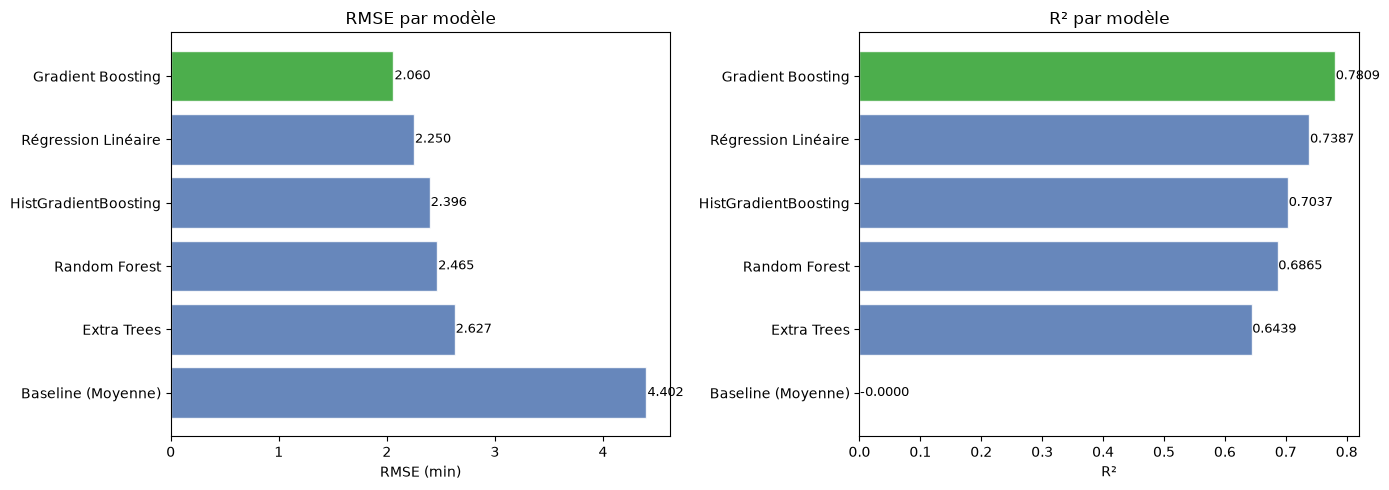

In [20]:
# Barplot comparatif RMSE / R² des modèles

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = results_df.index.tolist()
rmse_vals = results_df["RMSE"].tolist()
r2_vals = results_df["R²"].tolist()
colors = ["#4C72B0"] * len(names)
colors[0] = "#2ca02c"  # meilleur modèle en vert

# RMSE
axes[0].barh(names, rmse_vals, color=colors, edgecolor="white", alpha=0.85)
axes[0].set_title("RMSE par modèle")
axes[0].set_xlabel("RMSE (min)")
axes[0].invert_yaxis()
for i, v in enumerate(rmse_vals):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

# R²
axes[1].barh(names, r2_vals, color=colors, edgecolor="white", alpha=0.85)
axes[1].set_title("R² par modèle")
axes[1].set_xlabel("R²")
axes[1].invert_yaxis()
for i, v in enumerate(r2_vals):
    axes[1].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [21]:
# CROSS-VALIDATION: Validation croisée à 5 plis

print("Calcul de la validation croisée (5 plis) pour chaque modèle...")
print("   (Cette étape peut prendre quelques minutes)")

# Pipes à évaluer en CV
pipes_cv = {
    "Régression Linéaire": pipe_lr,
    "Random Forest": pipe_rf,
    "Gradient Boosting": pipe_gb,
    "Extra Trees": pipe_et,
    "HistGradientBoosting": pipe_hgb,
}

cv_results = {}

for name, pipe in pipes_cv.items():
    scores = cross_val_score(
        pipe,
        X,
        y,
        cv=5,  # 5 plis
        scoring="neg_root_mean_squared_error",  # RMSE négatif
        n_jobs=-1,  # Parallélisation
    )
    cv_results[name] = {
        "mean_rmse": -scores.mean(),  # RMSE moyen (positif)
        "std_rmse": scores.std(),  # Écart-type du RMSE
        "scores": -scores,  # Tous les scores
    }
    print(f"   {name} : RMSE = {-scores.mean():.3f} ± {scores.std():.3f}")

Calcul de la validation croisée (5 plis) pour chaque modèle...
   (Cette étape peut prendre quelques minutes)
   Régression Linéaire : RMSE = 2.062 ± 0.570
   Random Forest : RMSE = 2.113 ± 0.560
   Gradient Boosting : RMSE = 1.885 ± 0.501
   Extra Trees : RMSE = 2.380 ± 0.454
   HistGradientBoosting : RMSE = 1.936 ± 0.595


### Résultats de la validation croisée

Comparaison de la stabilité de chaque modèle sur 5 plis : un bon modèle doit avoir à la fois un RMSE moyen faible **et** un écart-type faible (= résultats reproductibles).

,RMSE moyen,Écart-type
Gradient Boosting,1.885,0.501
HistGradientBoosting,1.936,0.595
Régression Linéaire,2.062,0.570
Random Forest,2.113,0.560
Extra Trees,2.380,0.454


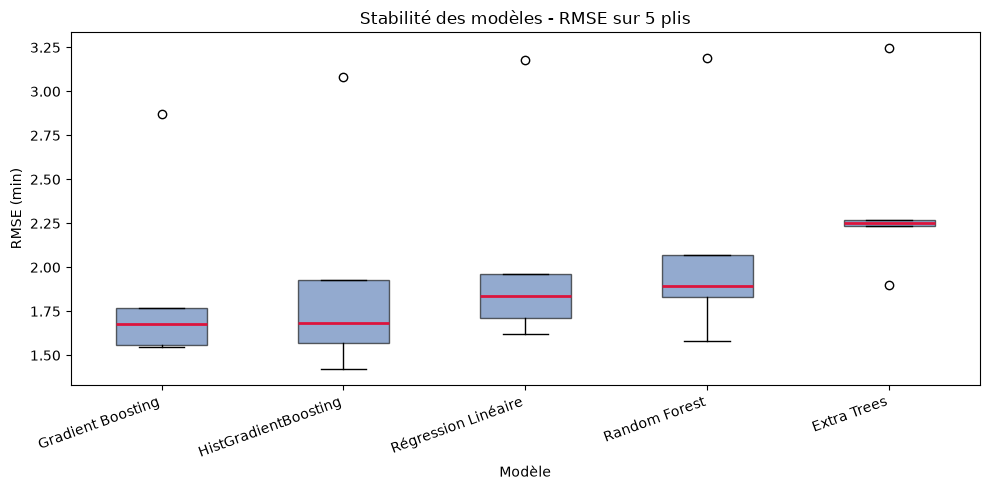

In [25]:
# Visualisation des résultats de validation croisée

cv_summary = pd.DataFrame(
    {
        name: {"RMSE moyen": v["mean_rmse"], "Écart-type": v["std_rmse"]}
        for name, v in cv_results.items()
    }
).T.sort_values("RMSE moyen")

display(
    cv_summary.style.background_gradient(subset=["RMSE moyen"], cmap="RdYlGn_r")
    .background_gradient(subset=["Écart-type"], cmap="RdYlGn_r")
    .format({"RMSE moyen": "{:.3f}", "Écart-type": "{:.3f}"})
)

# Boxplot des scores CV par modèle
fig, ax = plt.subplots(figsize=(10, 5))
data_box = [cv_results[name]["scores"] for name in cv_summary.index]
ax.boxplot(
    data_box,
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0", alpha=0.6),
    medianprops=dict(color="crimson", linewidth=2),
)
ax.set_xticks(range(1, len(data_box) + 1))
ax.set_xticklabels(cv_summary.index, rotation=20, ha="right")
ax.set_title("Stabilité des modèles - RMSE sur 5 plis")
ax.set_ylabel("RMSE (min)")
ax.set_xlabel("Modèle")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning

Après avoir identifié le meilleur modèle à l'étape 5, on l'optimise avec `RandomizedSearchCV`.

Cette méthode teste aléatoirement des combinaisons d'hyperparamètres au lieu d'explorer toute la grille (`GridSearchCV`), ce qui réduit fortement le temps de calcul tout en conservant de bonnes performances.

Chaque modèle possède sa propre grille, couvrant :
- `n_estimators` / `max_iter`: nombre d'arbres ou d'itérations de boosting
- `max_depth`: profondeur maximale des arbres (contrôle l'overfitting)
- `learning_rate`: vitesse d'apprentissage pour les modèles de boosting
- `max_features`: sous-ensemble de features considérées à chaque split
- `min_samples_leaf`: taille minimale des feuilles (lisse les prédictions)
- `l2_regularization`: pénalité L2 sur les poids (HistGradientBoosting)

Le tuning est évalué par validation croisée à 5 plis avec le **RMSE** comme métrique cohérent avec l'étape d'évaluation. Un mécanisme anti-dégradation conserve le modèle original si le tuning dégrade les performances.

In [26]:
warnings.filterwarnings("ignore", message=".*delayed.*")
IS_CI = os.getenv("CI") == "true"

n_iter = 10 if IS_CI else 50
cv = 3 if IS_CI else 5

# Chaque clé correspond au nom affiché dans le tableau de résultats
pipes = {
    "Baseline (Moyenne)": baseline,
    "Régression Linéaire": pipe_lr,
    "Random Forest": pipe_rf,
    "Gradient Boosting": pipe_gb,
    "Extra Trees": pipe_et,
    "HistGradientBoosting": pipe_hgb,
}

# Pipeline du meilleur modèle initial
best_pipe = pipes[best_model_name]
best_estimator = best_pipe.named_steps["model"]

print(f"Modèle sélectionné pour le tuning : {best_model_name}")
print(f"Type du modèle : {type(best_estimator).__name__}")

param_grids = {
    "Random Forest": {
        "model__n_estimators": [300, 500, 700],
        "model__max_depth": [None, 15, 25, 35],
        "model__max_features": ["sqrt", "log2", 0.4, 0.6],
        "model__min_samples_split": [2, 4, 8],
        "model__min_samples_leaf": [1, 2, 3],
        "model__bootstrap": [True, False],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.005, 0.01, 0.05, 0.1],
        "model__max_depth": [3, 4],
        "model__subsample": [0.7, 0.8, 0.9, 1.0],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
    },
    "Extra Trees": {
        "model__n_estimators": [300, 500, 700],
        "model__max_depth": [None, 15, 25, 35],
        "model__max_features": ["sqrt", "log2", 0.4, 0.6],
        "model__min_samples_split": [2, 4, 8],
        "model__min_samples_leaf": [1, 2, 3],
        "model__bootstrap": [True, False],
    },
    "HistGradientBoosting": {
        "model__max_iter": [300, 500, 700],
        "model__learning_rate": [0.005, 0.01, 0.05, 0.1],
        "model__max_depth": [4, 6, 8, 10, None],
        "model__min_samples_leaf": [10, 20, 30, 50],
        "model__l2_regularization": [0.0, 0.05, 0.1, 0.5, 1.0],
        "model__max_bins": [128, 255],
    },
    "Régression Linéaire": {
        "model__fit_intercept": [True, False],
    },
    "Baseline (Moyenne)": {
        "model__strategy": ["mean"],
    },
}

# Sauvegarde du modèle initial (sécurité)
best_model_before = best_pipe

if best_model_name in param_grids:
    random_search = RandomizedSearchCV(
        estimator=best_pipe,
        param_distributions=param_grids[best_model_name],
        n_iter=n_iter,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        verbose=2,
        random_state=SEED,
    )

    print(f"Tuning de : {best_model_name} (30 itérations, CV=5)...")
    random_search.fit(X_train, y_train)

    tuned_model = random_search.best_estimator_

    # Prédictions
    y_pred_before = best_model_before.predict(X_test)
    y_pred_after = tuned_model.predict(X_test)

    # Métriques
    rmse_before = np.sqrt(mean_squared_error(y_test, y_pred_before))
    rmse_after = np.sqrt(mean_squared_error(y_test, y_pred_after))

    print(f"\nRMSE avant tuning : {rmse_before:.4f}")
    print(f"RMSE après tuning : {rmse_after:.4f}")

    # Anti-dégradation
    if rmse_after < rmse_before:
        final_model = tuned_model
        print(
            f"Modèle retenu : version TUNED  (gain = {rmse_before - rmse_after:.4f} min)"
        )
    else:
        final_model = best_model_before
        print("Modèle retenu : version ORIGINALE (tuning rejeté — pas d'amélioration)")

else:
    print(f"Pas de grille définie pour '{best_model_name}' — tuning ignoré.")
    final_model = best_pipe

Modèle sélectionné pour le tuning : Gradient Boosting
Type du modèle : GradientBoostingRegressor
Tuning de : Gradient Boosting (30 itérations, CV=5)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END model__learning_rate=0.05, model__max_depth=4, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200, model__subsample=0.7; total time=  18.6s
[CV] END model__learning_rate=0.05, model__max_depth=4, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200, model__subsample=0.7; total time=  19.2s
[CV] END model__learning_rate=0.05, model__max_depth=4, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200, model__subsample=0.7; total time=  19.9s
[CV] END model__learning_rate=0.05, model__max_depth=4, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=200, model__subsample=0.7; total time=  21.1s
[CV] END model__learning_rate=0.05, model__max_depth=4, model__min_samples_lea

In [27]:
# Métriques du modèle final

y_pred_tuned = final_model.predict(X_test)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Modèle final — métriques sur le test set :")
print(f"   RMSE : {rmse_tuned:.4f} min")
print(f"   MAE  : {mae_tuned:.4f} min")
print(f"   R²   : {r2_tuned:.4f}")

Modèle final — métriques sur le test set :
   RMSE : 1.8286 min
   MAE  : 1.0058 min
   R²   : 0.8274


### Importance des features

Les features les plus importantes donnent une réponse directe à l'objectif du projet : **identifier les causes opérationnelles qui expliquent les retards**.

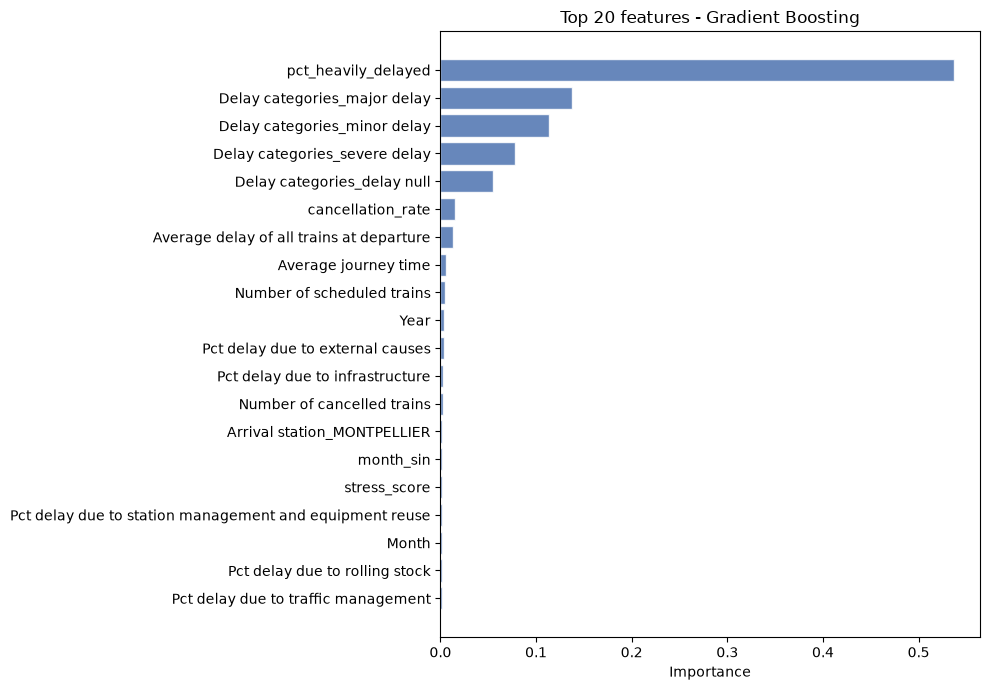


Top 10 causes opérationnelles :
   pct_heavily_delayed                                     0.5373
   Delay categories_major delay                            0.1373
   Delay categories_minor delay                            0.1132
   Delay categories_severe delay                           0.0777
   Delay categories_delay null                             0.0551
   cancellation_rate                                       0.0156
   Average delay of all trains at departure                0.0137
   Average journey time                                    0.0062
   Number of scheduled trains                              0.0046
   Year                                                    0.0036


In [28]:
# Feature importance du modèle final (modèles à base d'arbres)

estimator = final_model.named_steps["model"]

if hasattr(estimator, "feature_importances_"):
    preprocessor_fitted = final_model.named_steps["preprocessor"]

    # Récupération des noms de features après transformation
    num_names = num_in_X
    cat_names = list(
        preprocessor_fitted.named_transformers_["categorical"]
        .named_steps["encoder"]
        .get_feature_names_out(cat_in_X)
    )
    all_feature_names = num_names + cat_names

    importances = estimator.feature_importances_
    feat_imp_df = (
        pd.DataFrame({"Feature": all_feature_names, "Importance": importances})
        .sort_values("Importance", ascending=False)
        .head(20)
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(
        feat_imp_df["Feature"],
        feat_imp_df["Importance"],
        color="#4C72B0",
        edgecolor="white",
        alpha=0.85,
    )
    ax.invert_yaxis()
    ax.set_title(f"Top 20 features - {best_model_name}")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print("\nTop 10 causes opérationnelles :")
    for i, row in feat_imp_df.head(10).iterrows():
        print(f"   {row['Feature']:<55} {row['Importance']:.4f}")
else:
    print(f"Le modèle {best_model_name} ne supporte pas feature_importances_.")

## 7. Sauvegarde du modèle

In [29]:
# SAUVEGARDE DU PIPELINE COMPLET

# Le modèle final respecte la logique anti-dégradation (tuned ou original)
final_pipeline = final_model

# Chemin de sauvegarde
model_path = "model.joblib"

# Sauvegarder avec compression niveau 3 (bon compromis taille/vitesse)
joblib.dump(final_pipeline, model_path, compress=3)

file_size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"Modèle sauvegardé : {model_path}")
print(f"   Taille du fichier : {file_size_mb:.2f} MB")
print(f"   Meilleurs hyperparamètres : {random_search.best_params_}")

# Vérification de la sauvegarde
loaded_pipeline = joblib.load(model_path)
y_pred_loaded = loaded_pipeline.predict(X_test)
rmse_loaded = np.sqrt(mean_squared_error(y_test, y_pred_loaded))

print("\nVérification du modèle chargé :")
print(f"   RMSE (chargé) : {rmse_loaded:.4f}")
print(f"   RMSE (original) : {rmse_tuned:.4f}")
print(f"   Identique : {'OUI' if abs(rmse_loaded - rmse_tuned) < 1e-6 else 'NON'}")

# Sauvegarder les métadonnées du modèle

metadata = {
    "model_type": f"{type(final_model.named_steps['model']).__name__} (RandomizedSearchCV tuned)",
    "target": TARGET,
    "best_params": {k: str(v) for k, v in random_search.best_params_.items()},
    "test_rmse": float(rmse_tuned),
    "test_mae": float(mae_tuned),
    "test_r2": float(r2_tuned),
    "n_features": len(FEATURE_COLS),
    "feature_cols": FEATURE_COLS,
    "cat_cols": cat_in_X,
    "num_cols": num_in_X,
    "train_size": len(X_train),
    "test_size": len(X_test),
}

with open("model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("\nMétadonnées sauvegardées : model_metadata.json")

# Résumé final
print("\n" + "=" * 70)
print("RÉSUMÉ FINAL DU PROJET TARDIS — MODELING")
print("=" * 70)
print(f"   Dataset         : {df.shape[0]:,} observations × {df.shape[1]} colonnes")
print(f"   Features créées : {df_feat.shape[1] - df.shape[1]} nouvelles features")
print(f"   Meilleur modèle : {best_model_name} (après RandomizedSearchCV)")
print(f"   RMSE Test       : {rmse_tuned:.3f} minutes")
print(f"   MAE Test        : {mae_tuned:.3f} minutes")
print(f"   R² Test         : {r2_tuned:.4f}")
print(f"   Fichier modèle  : {model_path} ({file_size_mb:.1f} MB)")
print("=" * 70)

Modèle sauvegardé : model.joblib
   Taille du fichier : 0.12 MB
   Meilleurs hyperparamètres : {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 3, 'model__learning_rate': 0.1}

Vérification du modèle chargé :
   RMSE (chargé) : 1.8286
   RMSE (original) : 1.8286
   Identique : OUI

Métadonnées sauvegardées : model_metadata.json

RÉSUMÉ FINAL DU PROJET TARDIS — MODELING
   Dataset         : 11,478 observations × 28 colonnes
   Features créées : 7 nouvelles features
   Meilleur modèle : Gradient Boosting (après RandomizedSearchCV)
   RMSE Test       : 1.829 minutes
   MAE Test        : 1.006 minutes
   R² Test         : 0.8274
   Fichier modèle  : model.joblib (0.1 MB)
